In [275]:
# Import packages
import plotly.graph_objects as go
import pandas as pd
from scipy.stats import boxcox
from scipy.special import inv_boxcox
import pmdarima as pm
import numpy as np


In [276]:
data = pd.read_csv("../data/tsa-throughput-data-complete.csv")
data.columns = [t.partition('(')[0].strip().lower().replace(' ', '_') for t in data.columns]

In [277]:
data_proc = data.copy()
airport = 'ORD'

data_proc.drop(data_proc[data_proc['airport_code'] != airport].index, inplace=True)
data_proc.drop(data_proc[data_proc['total_passenger_throughput'] == 0].index, inplace=True)

data_proc['date'] = pd.to_datetime(data_proc['datetime']).dt.date
data_proc['month'] = pd.to_datetime(data_proc['datetime']).dt.month

#data_proc = data_proc[['datetime','total_passenger_throughput']]
#data_proc = data_proc.groupby(by=['date'],as_index=False).sum()
data_proc['datetime'] = pd.to_datetime(data_proc['datetime'])
data_proc = data_proc.groupby(pd.Grouper(key='datetime', freq='W'))['total_passenger_throughput'].sum().iloc[1:-1].reset_index() 

#data_proc['week'] = pd.to_datetime(data_proc['datetime']).dt.strftime('%U').astype(int)
data_proc['week'] = data_proc['datetime'].dt.isocalendar().week.astype(int)
#data_proc = data_proc.groupby(pd.Grouper(key='datetime', freq='W'))['total_passenger_throughput'].sum().iloc[1:-1]


In [278]:
data_proc = data_proc.iloc[:-int(len(data_proc) * 0.25)]

In [279]:
import plotly.express as px

def plot_passenger_volumes(df: pd.DataFrame,
                           x: str,
                           y: str,
                           airport: str) -> None:
    """General function to plot the passenger data."""

    fig = px.line(df, x=x, y=y, labels={'Month': 'Date'})
    fig.update_layout(template="simple_white", font=dict(size=18), 
                      title_text='Airport Passengers: '+airport,
                      width=650, title_x=0.5, height=400)

    return fig.show()


data_proc["total_passenger_throughput_diff"] = data_proc["total_passenger_throughput"].diff()
plot_passenger_volumes(df=data_proc, x='datetime', y='total_passenger_throughput', airport=airport)

In [280]:
# Make the data stationary
data_proc['passengers_boxcox'], lam = boxcox(data_proc['total_passenger_throughput'])
data_proc["passengers_boxcox_diff"] = data_proc["passengers_boxcox"].diff()
data_proc.dropna(inplace=True)

data_proc['passengers_log'] = np.log(data_proc['total_passenger_throughput'])
data_proc['passengers_log_diff'] = data_proc['passengers_log'].diff()

data_proc['total_passenger_throughput_diff'] = data_proc['total_passenger_throughput'].diff()

# Plot the stationary passenger data
plot_passenger_volumes(df=data_proc,x='datetime', y='total_passenger_throughput',airport=airport)

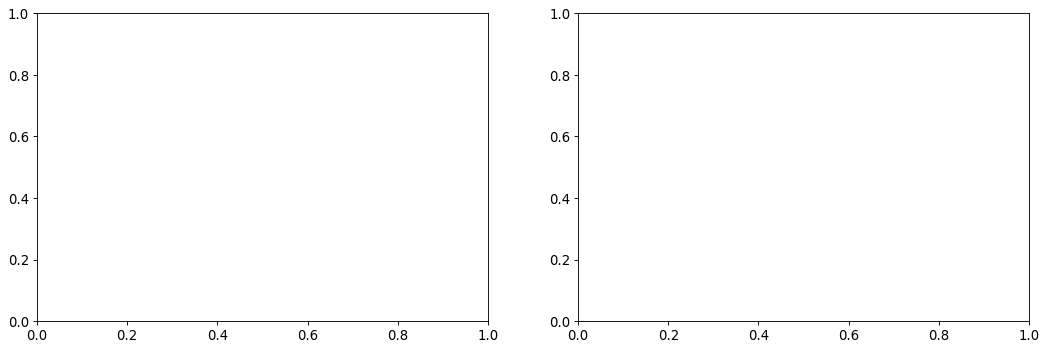

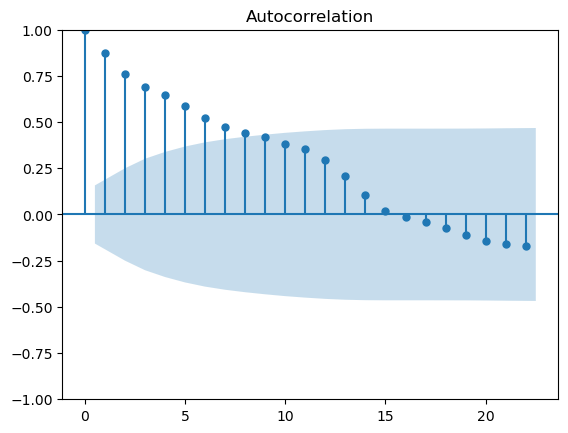

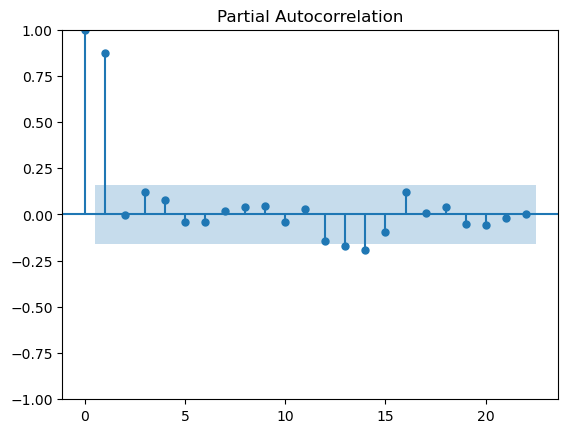

In [281]:
# Import packages
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

# Plot acf and pacf
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), dpi=80)
plot_acf(data_proc['passengers_boxcox'])
plot_pacf(data_proc['passengers_boxcox'])
ax1.tick_params(axis='both', labelsize=12)
ax2.tick_params(axis='both', labelsize=12)
plt.show()

In [282]:
#from pmdarima import auto_arima

#model = auto_arima(data_proc['passengers_boxcox'], 
#                   seasonal=True, 
#                   stepwise=True,
#                   m=52, 
#                   trace=True,
#                   information_criterion='aic')
#model.summary()

In [283]:
# Import packages
from scipy.special import inv_boxcox
from statsmodels.tsa.arima.model import ARIMA

# Split train and test
train = data_proc.iloc[:-int(len(data_proc) * 0.25)]
test = data_proc.iloc[-int(len(data_proc) * 0.25):]

# Build ARIMA model
#model = ARIMA(train['passengers_boxcox'], order=(1, 0, 0),
#              seasonal_order=(1, 1, 1, 52)).fit()
#ARIMA(0,1,0)(0,0,0)[0] 
#SARIMAX(p, d, q)x(P, D, Q, s)
model = ARIMA(train['passengers_boxcox'], 
              order=(2,1,2),
              seasonal_order=(1,1,0, 52)
              ).fit()
boxcox_forecasts = model.forecast(len(test))
forecasts = inv_boxcox(boxcox_forecasts, lam)

In [284]:
# Import packages
import plotly.graph_objects as go

def plot_forecasts(forecasts: list[float], title: str) -> None:
    """Function to plot the forecasts."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train['datetime'], y=train['total_passenger_throughput'], name='Train'))
    fig.add_trace(go.Scatter(x=test['datetime'], y=test['total_passenger_throughput'], name='Test'))
    fig.add_trace(go.Scatter(x=test['datetime'], y=forecasts, name='Forecast'))
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                      width=650, title_x=0.5, height=400, xaxis_title='Date',
                      yaxis_title='Passengers')

    return fig.show()

# Plot the forecasts
plot_forecasts(forecasts, 'SARIMA')

In [285]:
from sklearn.metrics import mean_absolute_percentage_error
mse = mean_squared_error(test['total_passenger_throughput'],forecasts)
mape = mean_absolute_percentage_error(test['total_passenger_throughput'],forecasts)
print(mape)

0.030339628909428283


In [286]:
# Get fourier features
for order in range(1, 10):
    data_proc[f'fourier_sin_order_{order}'] = np.sin(2 * np.pi * order * data_proc['week'] / 52)
    data_proc[f'fourier_cos_order_{order}'] = np.cos(2 * np.pi * order * data_proc['week'] / 52)

# name of fourier features
fourier_features = [i for i in list(data_proc) if i.startswith('fourier')]

data_proc['time_index'] = np.arange(len(data_proc))
exog_features = ['time_index'] + fourier_features

# Split train and test
train = data_proc.iloc[:-int(len(data_proc) * 0.15)]
test = data_proc.iloc[-int(len(data_proc) * 0.15):]

# Build auto-ARIMA model with fourier features
model = pm.auto_arima(train['total_passenger_throughput'],
                      X=train[exog_features],
                      seasonal=False,
                      stepwise=True,
                      suppress_warnings=True,
                      max_order=None,
                      information_criterion='aicc',
                      error_action="ignore")

# Get the forecasts and apply inverse box-cox transform
forecasts = model.predict(n_periods=len(test), X=test[exog_features])
#forecasts = inv_boxcox(boxcox_forecasts, lam)
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  132
Model:               SARIMAX(1, 0, 2)   Log Likelihood               -1556.092
Date:                Sun, 15 Mar 2026   AIC                           3158.184
Time:                        11:01:51   BIC                           3224.488
Sample:                             0   HQIC                          3185.127
                                - 132                                         
Covariance Type:                  opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
time_index           6157.0649   3180.435      1.936      0.053     -76.473    1.24e+04
fourier_sin_order_1  4801.9816   4.27e+04      0.112      0.910   -7.89e+04    8.85e+04
fourier_cos_orde

In [287]:
def plot_forecasts(forecasts: list[float], title: str) -> None:
    """Function to plot the forecasts."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train['datetime'], y=train['total_passenger_throughput'], name='Train'))
    fig.add_trace(go.Scatter(x=test['datetime'], y=test['total_passenger_throughput'], name='Test'))
    fig.add_trace(go.Scatter(x=test['datetime'], y=forecasts, name='Forecast'))
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                      width=650, title_x=0.5, height=400, xaxis_title='Date',
                      yaxis_title='Passenger Volume')

    return fig.show()


# Plot the forecasts
plot_forecasts(forecasts, 'Harmonic Regression')

In [261]:
from sklearn.metrics import mean_absolute_percentage_error
mse = mean_squared_error(test['total_passenger_throughput'],forecasts)
mape = mean_absolute_percentage_error(test['total_passenger_throughput'],forecasts)
print(mape)

0.07751860811910553


In [220]:
import Forecasts
Forecasts.evaluate_forecast(test['total_passenger_throughput'], forecasts,"mymodel")


mymodel
  MAE:  49,651
  MAPE: 8.67%
  RMSE: 56,471


{'mae': np.float64(49651.26202919114),
 'mape': np.float64(8.674613899835053),
 'rmse': np.float64(56470.856889214105)}